In [1]:
!pip install yfinance

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time

In [3]:
end_date = datetime.today().strftime('%Y-%m-%d')
start_date = (datetime.today() - timedelta(days=365*10)).strftime('%Y-%m-%d')

df = yf.download('BTC-USD', start=start_date, end=end_date)
df.columns = df.columns.get_level_values(0)
df = df[['Close']].copy()
df.dropna(inplace=True)

print(f"Data from : {start_date}")
print(f"Data to   : {end_date}")
print(f"Total days: {len(df)}")
print(df.tail())

/tmp/ipykernel_11545/450756759.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('BTC-USD', start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed

Data from : 2016-04-05
Data to   : 2026-04-03
Total days: 3650
Price              Close
Date                    
2026-03-29  65954.921875
2026-03-30  66691.445312
2026-03-31  68233.312500
2026-04-01  68078.554688
2026-04-02  66888.570312


In [4]:
df['Lag1'] = df['Close'].shift(1)
df['Lag2'] = df['Close'].shift(2)
df['Lag3'] = df['Close'].shift(3)
df.dropna(inplace=True)
print(df.tail())

Price              Close          Lag1          Lag2          Lag3
Date                                                              
2026-03-29  65954.921875  66319.695312  66338.375000  68791.625000
2026-03-30  66691.445312  65954.921875  66319.695312  66338.375000
2026-03-31  68233.312500  66691.445312  65954.921875  66319.695312
2026-04-01  68078.554688  68233.312500  66691.445312  65954.921875
2026-04-02  66888.570312  68078.554688  68233.312500  66691.445312


In [6]:
X = df[['Lag1', 'Lag2', 'Lag3']]
y_price = df['Close']
y_trend = (df['Close'] > df['Lag1']).astype(int)

print("X shape:", X.shape)
print("y_price shape:", y_price.shape)
print("y_trend value counts:\n", y_trend.value_counts())

X shape: (3647, 3)
y_price shape: (3647,)
y_trend value counts:
 1    1917
0    1730
Name: count, dtype: int64


In [7]:
X_train, X_test, yp_train, yp_test = train_test_split(X, y_price, test_size=0.2, shuffle=False)
_, _, yt_train, yt_test = train_test_split(X, y_trend, test_size=0.2, shuffle=False)

print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 2917
Test size: 730


In [18]:

lr = LinearRegression()
lr.fit(X_train, yp_train)

log = LogisticRegression()
log.fit(X_train, yt_train)

print("Models trained successfully!")

Models trained successfully!


In [19]:

yp_pred = lr.predict(X_test)
print(" Linear Regression (Price) ")
print(f"RMSE : {np.sqrt(mean_squared_error(yp_test, yp_pred)):.2f}")
print(f"R²   : {r2_score(yp_test, yp_pred):.4f}")


yt_pred = log.predict(X_test)
print("\n Logistic Regression (Trend) ")
print(f"Accuracy : {accuracy_score(yt_test, yt_pred):.4f}")
print(classification_report(yt_test, yt_pred, target_names=['Down', 'Up']))

 Linear Regression (Price) 
RMSE : 2047.05
R²   : 0.9889

 Logistic Regression (Trend) 
Accuracy : 0.5055
              precision    recall  f1-score   support

        Down       0.51      0.91      0.65       369
          Up       0.50      0.10      0.16       361

    accuracy                           0.51       730
   macro avg       0.50      0.50      0.41       730
weighted avg       0.50      0.51      0.41       730



In [20]:
last_known = df['Close'].values[-3:].flatten()

future_prices = []
future_trends = []
future_dates = []

prev_price = last_known[-1]

for i in range(30):
    lag1, lag2, lag3 = last_known[-1], last_known[-2], last_known[-3]
    input_features = np.array([[lag1, lag2, lag3]])


    next_price = float(lr.predict(input_features)[0])


    trend = 'Up 📈' if next_price > prev_price else 'Down 📉'

    future_prices.append(next_price)
    future_trends.append(trend)
    future_dates.append((datetime.today() + timedelta(days=i+1)).strftime('%Y-%m-%d'))

    prev_price = next_price
    last_known = np.append(last_known, next_price)

future_df = pd.DataFrame({
    'Date': future_dates,
    'Predicted Price (USD)': [f"${p:,.2f}" for p in future_prices],
    'Trend': future_trends
})

print(f"Predictions starting from: {datetime.today().strftime('%Y-%m-%d')}")
print(future_df.to_string(index=False))

Predictions starting from: 2026-04-03
      Date Predicted Price (USD)  Trend
2026-04-04            $66,951.61   Up 📈
2026-04-05            $66,949.13 Down 📉
2026-04-06            $66,962.42   Up 📈
2026-04-07            $66,974.34   Up 📈
2026-04-08            $66,986.48   Up 📈
2026-04-09            $66,998.60   Up 📈
2026-04-10            $67,010.71   Up 📈
2026-04-11            $67,022.83   Up 📈
2026-04-12            $67,034.94   Up 📈
2026-04-13            $67,047.04   Up 📈
2026-04-14            $67,059.15   Up 📈
2026-04-15            $67,071.25   Up 📈
2026-04-16            $67,083.35   Up 📈
2026-04-17            $67,095.45   Up 📈
2026-04-18            $67,107.54   Up 📈
2026-04-19            $67,119.64   Up 📈
2026-04-20            $67,131.72   Up 📈
2026-04-21            $67,143.81   Up 📈
2026-04-22            $67,155.90   Up 📈
2026-04-23            $67,167.98   Up 📈
2026-04-24            $67,180.06   Up 📈
2026-04-25            $67,192.13   Up 📈
2026-04-26            $67,204.21   Up 📈
20

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/

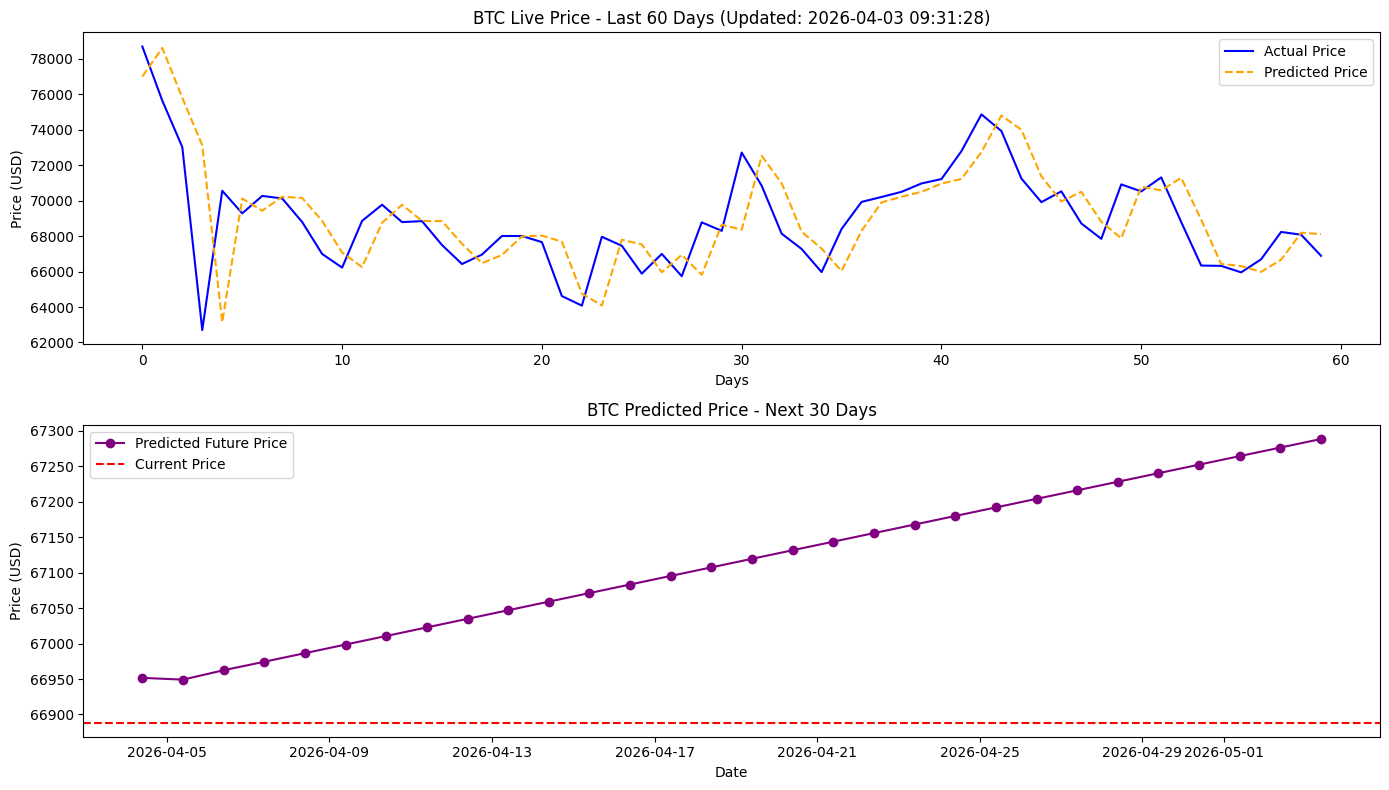

Current BTC Price : $66,888.57
Predicted Day 30  : $67,288.66
30 Day Outlook    : Bullish 📈

Next update in 60 seconds... (5/5)


In [21]:
def update_graph():

    end_date = datetime.today().strftime('%Y-%m-%d')
    start_date = (datetime.today() - timedelta(days=365*10)).strftime('%Y-%m-%d')

    live_df = yf.download('BTC-USD', start=start_date, end=end_date)
    live_df.columns = live_df.columns.get_level_values(0)
    live_df = live_df[['Close']].copy()
    live_df.dropna(inplace=True)

    live_df['Lag1'] = live_df['Close'].shift(1)
    live_df['Lag2'] = live_df['Close'].shift(2)
    live_df['Lag3'] = live_df['Close'].shift(3)
    live_df.dropna(inplace=True)

    X_live = live_df[['Lag1', 'Lag2', 'Lag3']]
    y_live_price = live_df['Close']
    y_live_pred = lr.predict(X_live)


    future_dates_plot = [datetime.today() + timedelta(days=i+1) for i in range(30)]

    clear_output(wait=True)
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))


    ax1.plot(live_df['Close'].values[-60:], label='Actual Price', color='blue')
    ax1.plot(y_live_pred[-60:], label='Predicted Price', color='orange', linestyle='--')
    ax1.set_title(f'BTC Live Price - Last 60 Days (Updated: {datetime.today().strftime("%Y-%m-%d %H:%M:%S")})')
    ax1.set_xlabel('Days')
    ax1.set_ylabel('Price (USD)')
    ax1.legend()


    ax2.plot(future_dates_plot, future_prices, marker='o', color='purple', label='Predicted Future Price')
    ax2.axhline(y=live_df['Close'].values[-1], color='red', linestyle='--', label='Current Price')
    ax2.set_title('BTC Predicted Price - Next 30 Days')
    ax2.set_xlabel('Date')
    ax2.set_ylabel('Price (USD)')
    ax2.legend()

    plt.tight_layout()
    plt.show()
    print(f"Current BTC Price : ${live_df['Close'].values[-1]:,.2f}")
    print(f"Predicted Day 30  : ${future_prices[-1]:,.2f}")
    print(f"30 Day Outlook    : {'Bullish 📈' if future_prices[-1] > live_df['Close'].values[-1] else 'Bearish 📉'}")


for i in range(5):
    update_graph()
    print(f"\nNext update in 60 seconds... ({i+1}/5)")
    time.sleep(60)

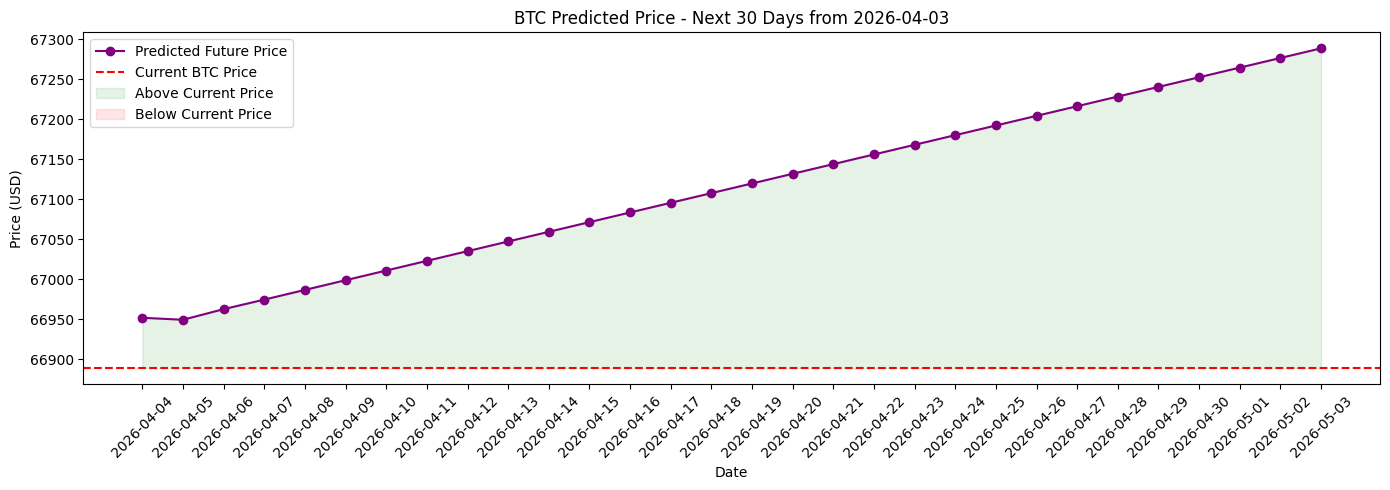

In [22]:
plt.figure(figsize=(14, 5))
plt.plot(future_dates, future_prices, marker='o', color='purple', label='Predicted Future Price')
plt.axhline(y=df['Close'].values[-1], color='red', linestyle='--', label='Current BTC Price')
plt.fill_between(future_dates, future_prices, df['Close'].values[-1],
                  where=[p > df['Close'].values[-1] for p in future_prices],
                  color='green', alpha=0.1, label='Above Current Price')
plt.fill_between(future_dates, future_prices, df['Close'].values[-1],
                  where=[p < df['Close'].values[-1] for p in future_prices],
                  color='red', alpha=0.1, label='Below Current Price')
plt.title(f'BTC Predicted Price - Next 30 Days from {datetime.today().strftime("%Y-%m-%d")}')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [24]:
print("=" * 50)
print("        BTC MARKET PREDICTION SUMMARY")
print("=" * 50)
print(f"\n Model Performance:")
print(f"   Linear Regression  RMSE : {np.sqrt(mean_squared_error(yp_test, yp_pred)):.2f}")
print(f"   Linear Regression  R²   : {r2_score(yp_test, yp_pred):.4f}")
print(f"   Logistic Regression Accuracy : {accuracy_score(yt_test, yt_pred):.4f}")

print(f"\n Prediction Date   : {datetime.today().strftime('%Y-%m-%d')}")
print(f" Current BTC Price : ${df['Close'].values[-1]:,.2f}")
print(f" Predicted Day 1   : ${future_prices[0]:,.2f}")
print(f" Predicted Day 30  : ${future_prices[-1]:,.2f}")

change = future_prices[-1] - df['Close'].values[-1]
change_pct = (change / df['Close'].values[-1]) * 100

print(f"\nExpected Change   : ${change:,.2f} ({change_pct:.2f}%)")
print(f"30 Day Outlook    : {'Bullish  (Price Rising)' if future_prices[-1] > df['Close'].values[-1] else 'Bearish  (Price Falling)'}")
print("=" * 50)

        BTC MARKET PREDICTION SUMMARY

 Model Performance:
   Linear Regression  RMSE : 2047.05
   Linear Regression  R²   : 0.9889
   Logistic Regression Accuracy : 0.5055

 Prediction Date   : 2026-04-03
 Current BTC Price : $66,888.57
 Predicted Day 1   : $66,951.61
 Predicted Day 30  : $67,288.66

Expected Change   : $400.09 (0.60%)
30 Day Outlook    : Bullish  (Price Rising)
